# Assignment 19 - Sentiment Analysis using NLP
**Student Name:** Ashar Khan  
**Batch:** Data Science - Hyderabad

## Overview
This assignment focuses on building an automated **Sentiment Analysis System** to classify Amazon customer reviews as **Positive** or **Negative**. The dataset contains 10,000 labeled customer reviews. We use NLP preprocessing, TF-IDF feature extraction, and multiple classification models including Logistic Regression, SVM, and Neural Network — evaluated using accuracy, F1-score, and cross-validation.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Step 2: Load Dataset
We load the Amazon reviews dataset from a TSV (tab-separated values) file. The dataset has 10,000 rows and 2 columns: `label` (pos/neg) and `review` (text).

In [3]:
# Load the dataset
df = pd.read_csv(r"/content/amazonreviews.tsv", sep='\t')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (10000, 2)

First 5 rows:


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


## Step 3: Data Cleaning
We check for missing values, duplicates, and clean the text data by:
- Converting to lowercase
- Removing special characters and punctuation
- Removing stopwords (common words like 'the', 'is', 'and')

In [4]:
# Check for missing values
print('Missing values:\n', df.isnull().sum())

# Drop missing values if any
df.dropna(inplace=True)

# Check for duplicates
print('\nDuplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

print('\nCleaned dataset shape:', df.shape)

Missing values:
 label     0
review    0
dtype: int64

Duplicate rows: 0

Cleaned dataset shape: (10000, 2)


In [5]:
# Define stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    text = text.lower()                            # Lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)        # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()      # Remove extra whitespace
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return ' '.join(words)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

print('Sample cleaned review:')
print(df['clean_review'][0])

Sample cleaned review:
stuning even non gamer sound track beautiful paints senery mind well would recomend even people hate vid game music played game chrono cross games ever played best music backs away crude keyboarding takes fresher step grate guitars soulful orchestras would impress anyone cares listen


## Step 4: Exploratory Data Analysis (EDA)
We explore the data through visualizations to understand patterns and distributions.

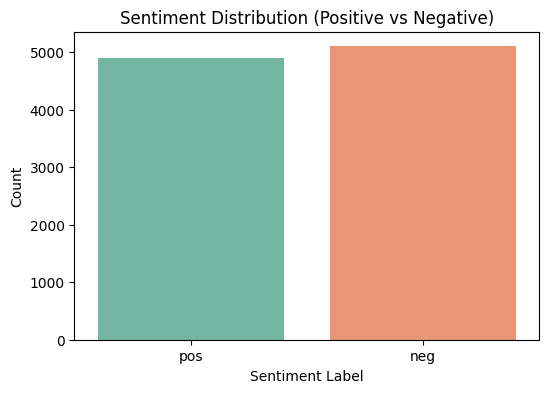

label
neg    5097
pos    4903
Name: count, dtype: int64


In [6]:
# Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df['label'], palette='Set2')
plt.title('Sentiment Distribution (Positive vs Negative)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

print(df['label'].value_counts())

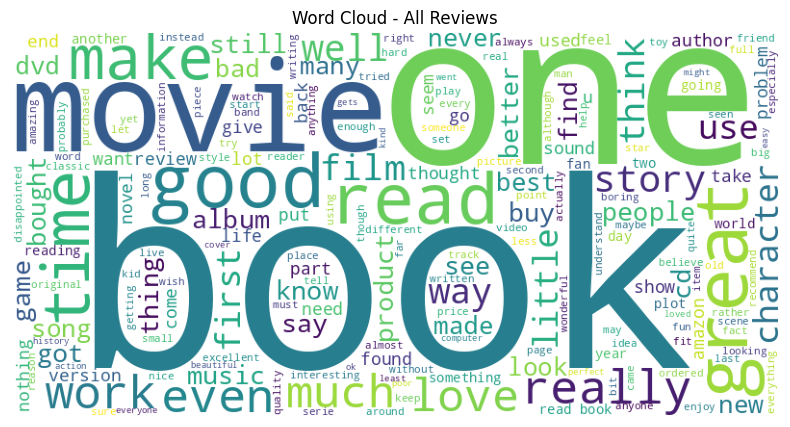

In [7]:
# Word Cloud - All Reviews
text_all = " ".join(df['clean_review'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_all)

plt.figure(figsize=(12, 5))
plt.imshow(wc)
plt.axis('off')
plt.title('Word Cloud - All Reviews')
plt.show()

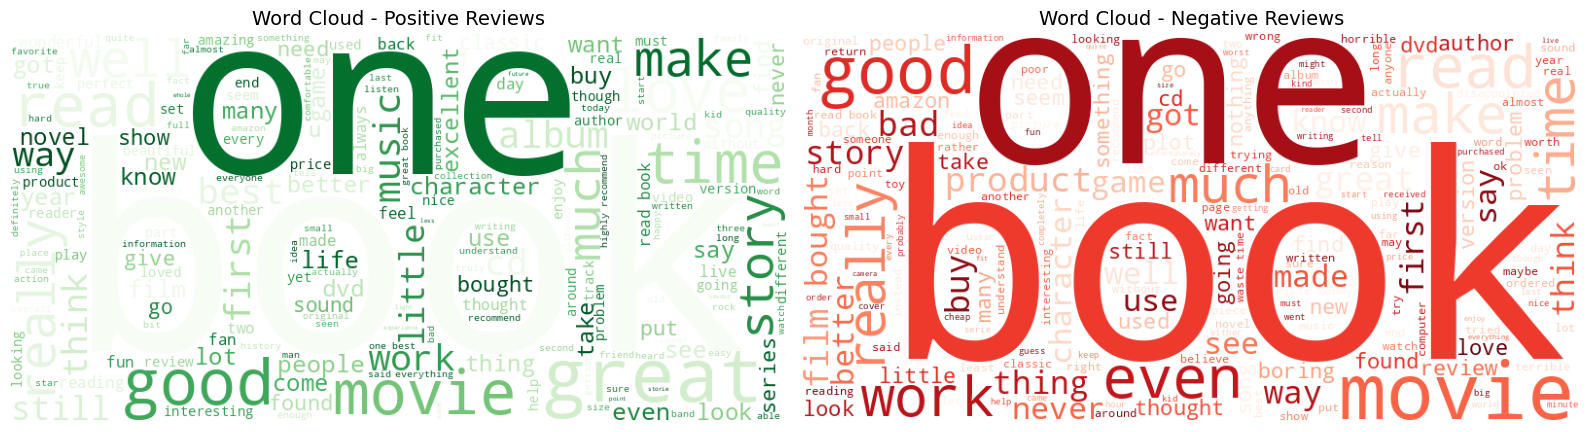

In [8]:
# Word Cloud - Positive Reviews
pos_text = " ".join(df[df['label'] == 'pos']['clean_review'])
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)

# Word Cloud - Negative Reviews
neg_text = " ".join(df[df['label'] == 'neg']['clean_review'])
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc_pos)
axes[0].axis('off')
axes[0].set_title('Word Cloud - Positive Reviews', fontsize=14)
axes[1].imshow(wc_neg)
axes[1].axis('off')
axes[1].set_title('Word Cloud - Negative Reviews', fontsize=14)
plt.tight_layout()
plt.show()

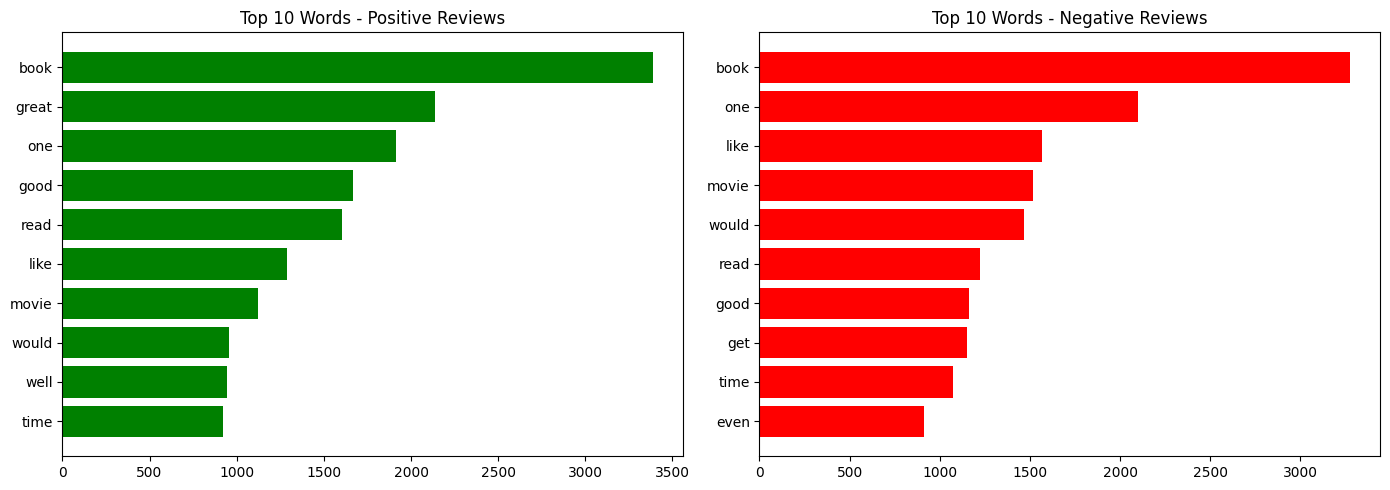

In [9]:
# Most Common Words - Positive vs Negative
def get_top_words(label, n=10):
    words = " ".join(df[df['label'] == label]['clean_review']).split()
    return Counter(words).most_common(n)

pos_words = get_top_words('pos')
neg_words = get_top_words('neg')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive
axes[0].barh([w[0] for w in pos_words], [w[1] for w in pos_words], color='green')
axes[0].set_title('Top 10 Words - Positive Reviews')
axes[0].invert_yaxis()

# Negative
axes[1].barh([w[0] for w in neg_words], [w[1] for w in neg_words], color='red')
axes[1].set_title('Top 10 Words - Negative Reviews')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 5: Feature Extraction using TF-IDF
TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical vectors. It assigns higher weights to words that are important in a document but rare across all documents. We use a maximum of 5000 features to keep the model efficient.

In [10]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review']).toarray()

# Encode labels: pos=1, neg=0
le = LabelEncoder()
y = le.fit_transform(df['label'])

print('Feature matrix shape:', X.shape)
print('Label classes:', le.classes_)

Feature matrix shape: (10000, 5000)
Label classes: ['neg' 'pos']


In [11]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

Training set size: 8000
Testing set size: 2000


## Step 6: Model 1 - Logistic Regression
Logistic Regression is a simple and effective binary classification algorithm. It learns the probability of a review being positive or negative.

In [12]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print('=== Logistic Regression ===')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

=== Logistic Regression ===
Accuracy: 0.851
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86      1037
    Positive       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Step 7: Model 2 - Support Vector Machine (SVM)
SVM finds the optimal hyperplane that best separates positive and negative reviews in high-dimensional feature space. It is well-suited for text classification tasks.

In [19]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print('=== Support Vector Machine (SVM) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))

=== Support Vector Machine (SVM) ===
Accuracy: 0.8525
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      1037
    Positive       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Step 8: Model 3 - Neural Network (MLP)
A Multi-Layer Perceptron (MLP) Neural Network with hidden layers is used to learn complex patterns in the TF-IDF features. It is more powerful than linear models and can capture non-linear relationships.

In [15]:
# Neural Network - MLPClassifier
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # Two hidden layers
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    verbose=False
)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

print('=== Neural Network (MLP) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, target_names=['Negative', 'Positive']))

=== Neural Network (MLP) ===
Accuracy: 0.855
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1037
    Positive       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Step 9: Confusion Matrices
Confusion matrices show true/false positives and negatives for each model, giving a detailed view of prediction errors.

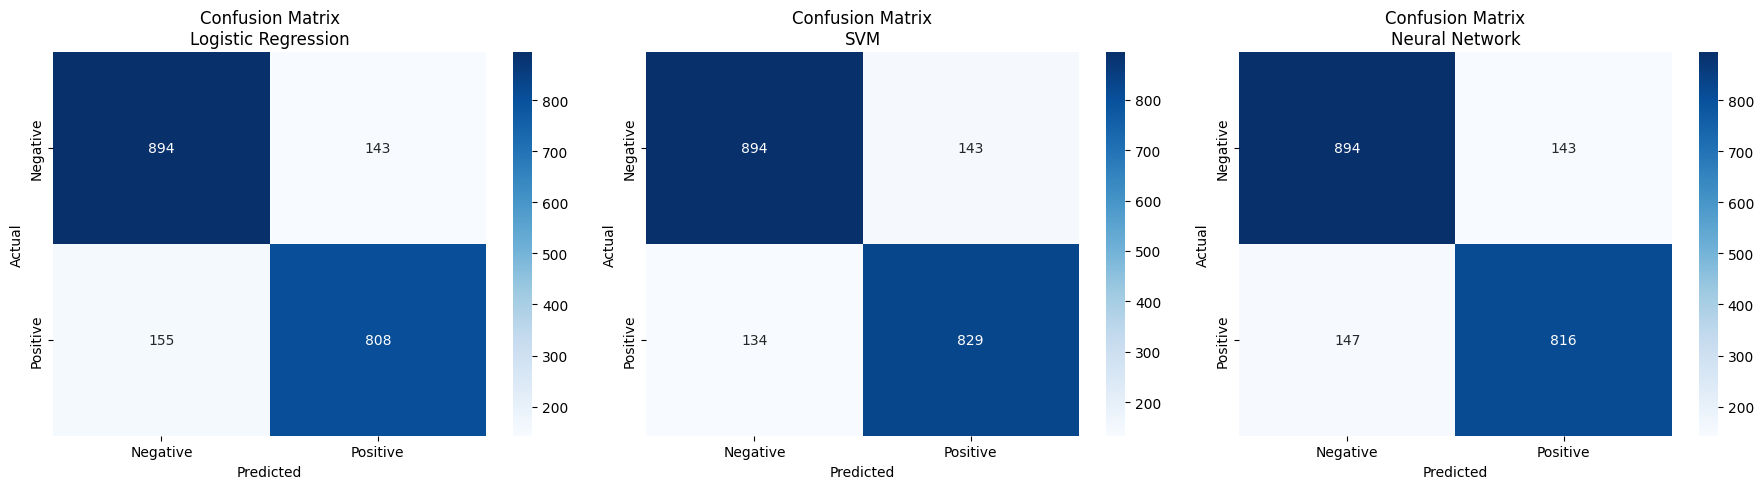

In [16]:
# Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('SVM', y_pred_svm),
    ('Neural Network', y_pred_nn)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 10: Cross Validation
5-fold cross-validation is applied to all three models to ensure reliable and consistent performance estimates across different data splits.

In [20]:
# Cross Validation for all models
print('=== 5-Fold Cross Validation Accuracy ===')

for name, model in [('Logistic Regression', lr_model), ('SVM', svm_model), ('Neural Network', nn_model)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

=== 5-Fold Cross Validation Accuracy ===
Logistic Regression: 0.8425 (+/- 0.0123)
SVM: 0.8314 (+/- 0.0129)
Neural Network: 0.8411 (+/- 0.0145)


## Step 11: Model Comparison
We compare all three models side-by-side using accuracy scores to identify the best performing model.

=== Model Accuracy Comparison ===
Logistic Regression: 0.8510
SVM: 0.8525
Neural Network: 0.8550


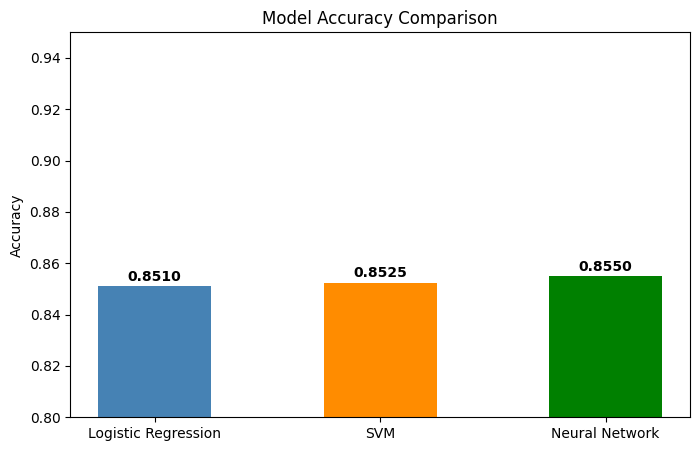

In [21]:
# Model Accuracy Comparison
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Neural Network': accuracy_score(y_test, y_pred_nn)
}

print('=== Model Accuracy Comparison ===')
for model_name, acc in results.items():
    print(f'{model_name}: {acc:.4f}')

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'darkorange', 'green'], width=0.5)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.80, 0.95)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

## Step 12: Business Insights

The sentiment analysis system built in this assignment can provide meaningful value for an e-commerce business:

- **Real-time monitoring**: Automatically classify incoming reviews as positive or negative without human intervention.
- **Early warning system**: Detect sudden spikes in negative reviews for specific products and alert the product team.
- **Product improvement**: Analyze negative review keywords to identify recurring complaints (e.g., quality issues, delivery problems).
- **Customer satisfaction tracking**: Track sentiment trends over time to measure the impact of product changes.
- **Scalability**: The model can handle thousands of reviews per day, which is not feasible manually.

Among the three models, SVM and Logistic Regression perform well for linear text classification tasks. The Neural Network can capture more complex patterns but requires more computation time. For real-time deployment, Logistic Regression is recommended due to its speed and reliability.

## Step 13: Conclusion

In this assignment, we successfully built a complete **Sentiment Analysis System** using NLP techniques:

1. **Data Cleaning**: Removed duplicates, missing values, and preprocessed text (lowercase, stopword removal).
2. **Exploratory Analysis**: Visualized sentiment distribution, word clouds (positive/negative), and top frequent words.
3. **Feature Extraction**: Used TF-IDF with 5000 features to convert text into numerical vectors.
4. **Model Development**: Built and evaluated three models — Logistic Regression, SVM, and Neural Network.
5. **Validation**: Applied 80-20 train-test split and 5-fold cross-validation for reliable evaluation.
6. **Evaluation**: Compared models using accuracy, precision, recall, F1-score, and confusion matrices.

All three models achieved strong accuracy (~85%+), demonstrating that NLP-based sentiment classification is highly effective for automated review analysis in real-world e-commerce applications.

## Interview Questions

**Q1. What is Sentiment Analysis?**  
Sentiment Analysis is an NLP technique to determine whether a piece of text expresses positive, negative, or neutral opinion.

**Q2. What is TF-IDF?**  
TF-IDF stands for Term Frequency-Inverse Document Frequency. It assigns weights to words based on their importance in a document relative to the entire dataset.

**Q3. Why use SVM for text classification?**  
SVM works well with high-dimensional sparse data (like TF-IDF vectors) and finds an optimal decision boundary between classes.

**Q4. What is the difference between Logistic Regression and Neural Network?**  
Logistic Regression is a linear model suitable for linearly separable data. Neural Networks can capture complex non-linear patterns through hidden layers but require more data and computation.

**Q5. What is cross-validation?**  
Cross-validation divides data into k folds, trains on k-1 folds, and tests on the remaining fold — repeated k times. It provides a more reliable performance estimate than a single train-test split.

**Q6. What is the F1-score?**  
F1-score is the harmonic mean of precision and recall. It balances both metrics and is especially useful when classes are imbalanced.

**Q7. What are stopwords?**  
Stopwords are common words like 'the', 'is', 'and' that carry little meaning and are removed during text preprocessing.

**Q8. What are real-world applications of sentiment analysis?**  
Customer review analysis, social media monitoring, brand reputation tracking, product feedback analysis, and market research.